In [3]:
from langgraph.graph import START, END, StateGraph
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal, Optional
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import pandas as pd
import os
import re
import json
import ast
from get_coordinates import get_city_coordinates
from air_quality import (
    get_current_air_quality,
    get_forecast_air_quality,
    clean_air_quality_data, 
    plot_air_quality_data
)
from weather import (
    get_current_weather,
    get_forecast_weather,
    clean_forecast_weather_data,
    plot_temperature_data,
    plot_rain_data,
    plot_wind_data
)
load_dotenv()

True

In [4]:
model = ChatOllama(
    model="deepseek-r1:1.5b",
    temperature=0.6,
    reasoning=True
)

In [19]:
# output = model.invoke("What course you would recommend to take a fresher studying in Computer Science?")
# output

In [20]:
# output.pretty_print()

In [75]:
class AirQuerySchema(BaseModel):
    query_type: Literal["current", "forecast"] = Field(
        description="Pick one of the air_quality query_type: 'current' or 'forecast'"
    )
    city_name: str = Field(description="City Name")
    country_code: str = Field(description="Country Code in ISO-3166-1 alpha-2")
    days: Optional[int] = Field(
        7, description="This field is required when using forecast"
    )

def air_query_prompt(user_input: str) -> str:
    return (
        "Extract structured information from this air quality query.\n"
        "Output ONLY a JSON object with: query_type ('current' or 'forecast'), city_name, country_code (ISO-2), days (integer, required only for 'forecast').\n"
        "Several examples:\n"
        "User query: 'What is air quality in Delhi, India today?'\n"
        "Output: {\"query_type\": \"current\", \"city_name\": \"Delhi\", \"country_code\": \"IN\"}\n"
        "User query: 'Air quality of Pune, India for next 3 days'\n"
        "Output: {\"query_type\": \"forecast\", \"city_name\": \"Pune\", \"country_code\": \"IN\", \"days\": 3}\n"
        "User query: 'What will be the air quality in San Francisco for the weekend?'\n"
        "Output: {\"query_type\": \"forecast\", \"city_name\": \"San Francisco\", \"country_code\": \"US\", \"days\": 2}\n"
        "User query: " + user_input + "\n"
        "Output:"
    )

def get_air_query_inputs(user_prompt: str, model) -> AirQuerySchema:
    prompt = air_query_prompt(user_prompt)
    result = model.invoke(prompt)
    text = result.content.strip()

    # Extract JSON or Python dict string
    try:
        if text.startswith("{") and text.endswith("}"):
            data = json.loads(text.replace("'", '"'))  # replace single quotes if needed
        else:
            # Try extracting from markdown block if present
            import re
            match = re.search(r"\{.*\}", text)
            data = json.loads(match.group().replace("'", '"')) if match else ast.literal_eval(text)
        return AirQuerySchema(**data)
    except Exception as e:
        print("Failed to parse schema:", e)
        return None

In [79]:
user_input = "What is Air Quality of Moscow, Rissia?"
prompt = get_air_query_inputs(user_input, model)
prompt

AirQuerySchema(query_type='current', city_name='Moscow', country_code='IN', days=0)

In [23]:
obj = get_air_query_inputs("What is Air Quality of Delhi, India?", model=model)
obj

Error parsing Python dict string: invalid syntax (<unknown>, line 1)
Error parsing LLM response: __main__.AirQuerySchema() argument after ** must be a mapping, not NoneType


In [71]:
from typing import TypedDict, Literal
import pandas as pd

# -----------------------------
# State Definition
# -----------------------------
class AirWFState(TypedDict, total=False):
    user_prompt: str
    query_type: Literal["current", "forecast"]
    city_name: str
    country_code: str
    days: int
    lat: float
    lon: float
    raw_data: dict
    df: pd.DataFrame
    make_plot: bool
    plot: str

# -----------------------------
# Node Functions
# -----------------------------
def start_air_graph(state: AirWFState) -> AirWFState:
    # Use LLM to extract structured inputs
    user_prompt = state["user_prompt"]
    schema = get_air_query_inputs(user_prompt, model)
    if schema is None:
        raise ValueError("Failed to extract info from user prompt.")
    return {
        **state,
        "query_type": schema.query_type,
        "city_name": schema.city_name.upper(),
        "country_code": schema.country_code,
        "days": schema.days
    }

def resolve_coords(state: AirWFState) -> AirWFState:
    coords = get_city_coordinates(state['city_name'], country_code=state['country_code'])
    lat = coords['lat']
    lon = coords['lon']
    return {**state, "lat": lat, "lon": lon}

def route_air_query(state: AirWFState) -> str:
    if state['query_type'] == "current":
        return "run_current_air"
    elif state['query_type'] == "forecast":
        return "run_forecast_air"
    else:
        raise ValueError(f"Unknown query_type: {state['query_type']}")

def run_current_air(state: AirWFState) -> AirWFState:
    data = get_current_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data, "make_plot": False}

def run_forecast_air(state: AirWFState) -> AirWFState:
    data = get_forecast_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data, "make_plot": True}

def clean_air_response(state: AirWFState) -> AirWFState:
    if state['query_type'] == "current":
        df = clean_air_quality_data(state['raw_data'].get("list"))
        return {**state, "df": df}
    elif state['query_type'] == "forecast":
        df = clean_air_quality_data(state["raw_data"].get("list"))
        return {**state, "df": df}
    else:
        raise ValueError(f"Invalid query_type for cleaning: {state['query_type']}")

def plot_forecast_air(state: AirWFState) -> AirWFState:
    if state.get("make_plot"):
        plot = plot_air_quality_data(state["df"], return_base64=True)
        return {**state, "plot": plot}
    return state

# -----------------------------
# Graph Definition
# -----------------------------
air_graph = StateGraph(AirWFState)

air_graph.add_node("start_air_graph", start_air_graph)
air_graph.add_node("resolve_coords", resolve_coords)
air_graph.add_node("run_current_air", run_current_air)
air_graph.add_node("run_forecast_air", run_forecast_air)
air_graph.add_node("clean_air_response", clean_air_response)
air_graph.add_node("plot_forecast_air", plot_forecast_air)

air_graph.set_entry_point("start_air_graph")
air_graph.add_edge("start_air_graph", "resolve_coords")

# conditional routing
air_graph.add_conditional_edges(
    "resolve_coords",
    route_air_query,
    {
        "run_current_air": "run_current_air",
        "run_forecast_air": "run_forecast_air"
    }
)

# shared cleaning stage
air_graph.add_edge("run_current_air", "clean_air_response")
air_graph.add_edge("run_forecast_air", "clean_air_response")

# plotting + end
air_graph.add_edge("clean_air_response", "plot_forecast_air")
air_graph.add_edge("plot_forecast_air", END)

air_graph_wf = air_graph.compile()

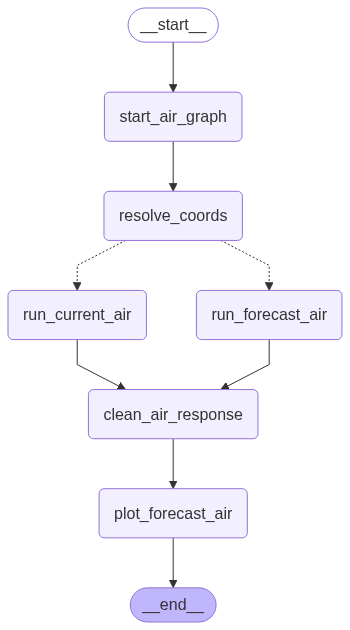

In [72]:
air_graph_wf

3/3 [==============================] - 0s 731us/step


{'user_prompt': 'air quality of berlin,Germany for 7 days?',
 'query_type': 'forecast',
 'city_name': 'BERLIN',
 'country_code': 'DE',
 'days': 7,
 'lat': 52.5170365,
 'lon': 13.3888599,
 'raw_data': {'coord': {'lon': 13.3889, 'lat': 52.517},
  'list': [{'main': {'aqi': 1},
    'components': {'co': 124.91,
     'no': 0.01,
     'no2': 6.52,
     'o3': 27.33,
     'so2': 0.6,
     'pm2_5': 2.43,
     'pm10': 5.82,
     'nh3': 7.2},
    'dt': 1755489600},
   {'main': {'aqi': 1},
    'components': {'co': 127.77,
     'no': 0.17,
     'no2': 7.53,
     'o3': 26.62,
     'so2': 0.78,
     'pm2_5': 2.55,
     'pm10': 5.97,
     'nh3': 7.42},
    'dt': 1755493200},
   {'main': {'aqi': 1},
    'components': {'co': 132.63,
     'no': 1.47,
     'no2': 7.7,
     'o3': 28.89,
     'so2': 1.05,
     'pm2_5': 2.69,
     'pm10': 6.2,
     'nh3': 7.84},
    'dt': 1755496800},
   {'main': {'aqi': 1},
    'components': {'co': 135.35,
     'no': 2.62,
     'no2': 6.76,
     'o3': 34.72,
     'so2': 1.4,
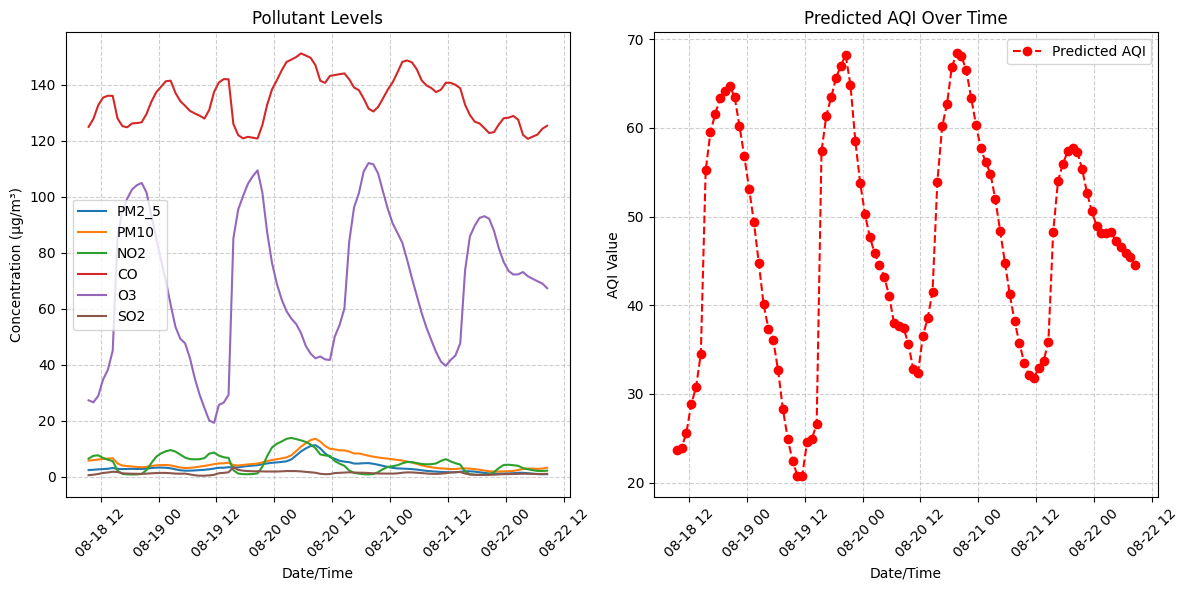

In [74]:
initial_state = {"user_prompt": "air quality of berlin,Germany for 7 days?"}
final_state = air_graph_wf.invoke(initial_state)
final_state

In [15]:
class AirCurrentState(TypedDict, total=False):
    city_name: str
    country_code: str
    lat: float
    lon: float
    raw_data: dict
    df: pd.DataFrame

In [16]:
def resolve_coords(state: AirCurrentState) -> AirCurrentState:
    coords = get_city_coordinates(state['city_name'], country_code=state['country_code'])
    lat = coords['lat']
    lon = coords['lon']
    return {**state, "lat": lat, "lon": lon}
def fetch_current(state: AirCurrentState) -> AirCurrentState:
    data = get_current_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data}

def clean_current(state: AirCurrentState) -> AirCurrentState:
    df = clean_air_quality_data(state["raw_data"].get("list"))
    return {**state, "df": df}

In [17]:
graph = StateGraph(AirCurrentState)

graph.add_node("resolve_coords", resolve_coords)
graph.add_node("fetch_current", fetch_current)
graph.add_node("clean_current", clean_current)

graph.set_entry_point("resolve_coords")
graph.add_edge("resolve_coords", "fetch_current")
graph.add_edge("fetch_current", "clean_current")
graph.add_edge("clean_current", END)

air_current_wf = graph.compile()

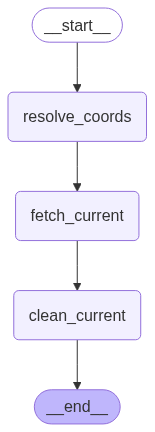

In [18]:
air_current_wf

In [19]:
initial_state = {"city_name": "Katihar", "country_code": "IN"}
final_state = air_current_wf.invoke(initial_state)
final_state

1/1 [==============================] - 0s 20ms/step


{'city_name': 'Katihar',
 'country_code': 'IN',
 'lat': 25.5433817,
 'lon': 87.5690417,
 'raw_data': {'coord': {'lon': 87.569, 'lat': 25.5434},
  'list': [{'main': {'aqi': 2},
    'components': {'co': 231.82,
     'no': 1.34,
     'no2': 10.84,
     'o3': 18.47,
     'so2': 8.45,
     'pm2_5': 11.59,
     'pm10': 13.72,
     'nh3': 1.1},
    'dt': 1755488127}]},
 'df':              datetime  aqi_index  pm2_5   pm10    no2      co     o3   so2  \
 0 2025-08-18 09:05:27          2  11.59  13.72  10.84  231.82  18.47  8.45   
 
    aqi_predicted  
 0       36.25502  }

In [20]:
class AirForecastState(TypedDict, total=False):
    city_name: str
    country_code: str
    days: int
    lat: float
    lon: float
    raw_data: dict
    df: pd.DataFrame
    plot: bool
    plot_path: Optional[str]

In [21]:
def resolve_coords(state: AirForecastState) -> AirForecastState:
    coords = get_city_coordinates(state['city_name'], country_code=state['country_code'])
    lat = coords['lat']
    lon = coords['lon']
    return {**state, "lat": lat, "lon": lon}

def fetch_forecast(state: AirForecastState) -> AirForecastState:
    data = get_forecast_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data}

def clean_forecast(state: AirForecastState) -> AirForecastState:
    df = clean_air_quality_data(state["raw_data"].get("list"))
    return {**state, "df": df}

def maybe_plot(state: AirForecastState) -> AirForecastState:
    if state.get("plot"):
        path = plot_air_quality_data(state["df"], return_base64=True)
        return {**state, "plot_path": path}
    return state

In [22]:
graph = StateGraph(AirForecastState)

graph.add_node("resolve_coords", resolve_coords)
graph.add_node("fetch_forecast", fetch_forecast)
graph.add_node("clean_forecast", clean_forecast)
graph.add_node("maybe_plot", maybe_plot)

graph.set_entry_point("resolve_coords")
graph.add_edge("resolve_coords", "fetch_forecast")
graph.add_edge("fetch_forecast", "clean_forecast")
graph.add_edge("clean_forecast", "maybe_plot")
graph.add_edge("maybe_plot", END)

air_forecast_wf = graph.compile()

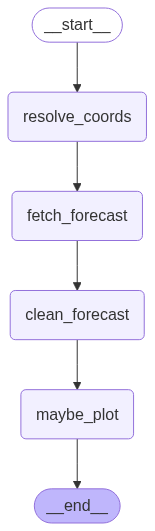

In [23]:
air_forecast_wf

In [24]:
initial_state = {"query_type": "now", "city_name": "Delhi", "country_code": "IN", "days": 3, "plot": True}
final_state = air_forecast_wf.invoke(initial_state)
# print(final_state)

3/3 [==============================] - 0s 643us/step


In [25]:
import base64
import io
from PIL import Image
import matplotlib.pyplot as plt

def show_base64_image(img_base64: str):
    """Display a base64 image string with matplotlib."""
    # Remove prefix if present ("data:image/png;base64,...")
    if img_base64.startswith("data:image"):
        img_base64 = img_base64.split(",")[1]
    
    # Decode base64 -> bytes
    img_bytes = base64.b64decode(img_base64)
    
    # Load as image
    img = Image.open(io.BytesIO(img_bytes))
    
    # Plot
    plt.figure(figsize=(20, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

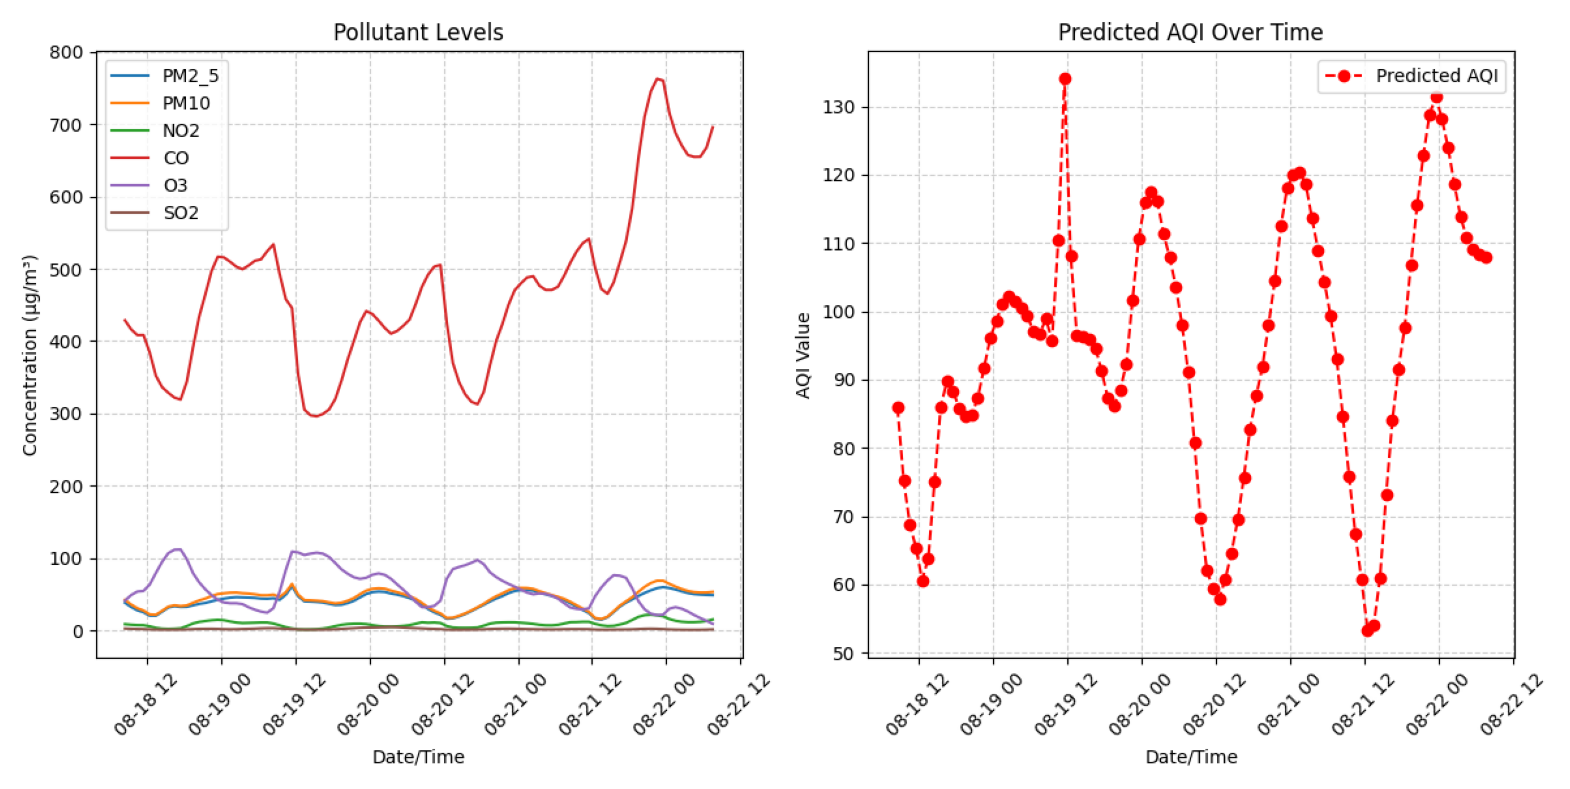

In [26]:
show_base64_image(final_state['plot_path'])

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal

class WeatherQuerySchema(BaseModel):
    query_type: Literal["current", "forecast"] = Field(
        description="Pick one of the Weather_quality query_type: 'current' or 'forecast'"
    )
    city_name: str = Field(description="City Name")
    country_code: str = Field(description="Country Code in ISO-3166-1 alpha-2")

def weather_query_prompt(user_input: str) -> str:
    return (
        "Extract structured information from this Weather quality query:\n"
        "Output as JSON with keys: query_type (either 'current' or 'forecast'), city_name, country_code (ISO-2 code if possible).\n\n"
        f"User query: {user_input}\n"
        "Example output: {\"query_type\": \"forecast\", \"city_name\": \"Delhi\", \"country_code\": \"IN\"}\n"
    )

def get_weather_query_inputs(user_input: str, model=model) -> WeatherQuerySchema:
    prompt = weather_query_prompt(user_input)
    model.with_structured_output(WeatherQuerySchema)
    result = model.invoke(prompt)
    text = result.content.strip()
    # Extract JSON part from response
    try:
        data = json.loads(text)
        schema = WeatherQuerySchema(**data)
    except Exception as e:
        print("Error parsing LLM response:", e)
        # Optionally fallback or handle manual extraction/ask model to try again
        schema = None
    return schema

In [ ]:
from typing import TypedDict, Literal
import pandas as pd

# -----------------------------
# State Definition
# -----------------------------
class WeatherWFState(TypedDict, total=False):
    user_prompt: str
    query_type: Literal["current", "forecast"]
    city_name: str
    country_code: str
    raw_data: dict
    df: pd.DataFrame
    make_plot: bool
    temp_plot: str
    rain_plot: str
    wind_plot: str

# -----------------------------
# Node Functions
# -----------------------------
def start_weather_graph(state: WeatherWFState) -> WeatherWFState:
    # Use LLM to extract structured inputs
    user_prompt = state["user_prompt"]
    schema = get_weather_query_inputs(user_prompt)
    if schema is None:
        raise ValueError("Failed to extract info from user prompt.")
    return {
        **state,
        "query_type": schema.query_type,
        "city_name": schema.city_name,
        "country_code": schema.country_code
    }

def route_weather_query(state: WeatherWFState) -> str:
    if state['query_type'] == "current":
        return "run_current_weather"
    elif state['query_type'] == "forecast":
        return "run_forecast_weather"
    else:
        raise ValueError(f"Unknown query_type: {state['query_type']}")

def run_current_weather(state: WeatherWFState) -> WeatherWFState:
    data = get_current_weather(state["lat"], state["lon"])
    return {**state, "raw_data": data, "make_plot": False}

def run_forecast_weather(state: WeatherWFState) -> WeatherWFState:
    data = get_forecast_weather(state["lat"], state["lon"])
    return {**state, "raw_data": data, "make_plot": True}

def clean_weather_response(state: WeatherWFState) -> WeatherWFState:
    if state['query_type'] == "current":
        raw_list = state['raw_data'].get("list") if isinstance(state['raw_data'], dict) else state['raw_data']
        df = clean_forecast_weather_data(raw_list)
        return {**state, "df": df}
    elif state['query_type'] == "forecast":
        df = clean_forecast_weather_data(state['raw_data'])
        return {**state, "df": df}
    else:
        raise ValueError(f"Invalid query_type for cleaning: {state['query_type']}")

def plot_forecast_weather(state: WeatherWFState) -> WeatherWFState:
    if state.get("make_plot"):
        temp_plot = plot_temperature_data(state["df"], return_base64=True)
        rain_plot = plot_rain_data(state["df"], return_base64=True)
        wind_plot = plot_wind_data(state["df"], return_base64=True)

        return {**state, "temp_plot": temp_plot, "rain_plot": rain_plot, "wind_plot": wind_plot}
    return state

# -----------------------------
# Graph Definition
# -----------------------------
weather_graph = StateGraph(WeatherWFState)

weather_graph.add_node("start_weather_graph", start_weather_graph)
weather_graph.add_node("resolve_coords", resolve_coords)
weather_graph.add_node("run_current_weather", run_current_weather)
weather_graph.add_node("run_forecast_weather", run_forecast_weather)
weather_graph.add_node("clean_weather_response", clean_weather_response)
weather_graph.add_node("plot_forecast_weather", plot_forecast_weather)

weather_graph.set_entry_point("start_weather_graph")
weather_graph.add_edge("start_weather_graph", "resolve_coords")

# conditional routing
weather_graph.add_conditional_edges(
    "resolve_coords",
    route_weather_query,
    {
        "run_current_weather": "run_current_weather",
        "run_forecast_weather": "run_forecast_weather"
    }
)

# shared cleaning stage
weather_graph.add_edge("run_current_weather", "clean_weather_response")
weather_graph.add_edge("run_forecast_weather", "clean_weather_response")

# plotting + end
weather_graph.add_edge("clean_weather_response", "plot_forecast_weather")
weather_graph.add_edge("plot_forecast_weather", END)

weather_graph_wf = weather_graph.compile()

In [5]:
from langchain_ollama import OllamaEmbeddings

embedding_model = OllamaEmbeddings(
    model="nomic-embed-text:latest",
    temperature=0.6,
    top_k=3
)

len(embedding_model.embed_query("Hello World"))

768

In [8]:
from langchain.prompts import PromptTemplate, FewShotPromptTemplate
from langchain.prompts.example_selector import SemanticSimilarityExampleSelector
from langchain.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings


# -------------------------------
# Step 1. Parse Example
# -------------------------------
def escape_braces(s: str) -> str:
    return s.replace("{", "{{").replace("}", "}}")
    
# -------------------------------
# Step 1. Define your examples
# -------------------------------
examples = [
    {"query": "What is air quality in Delhi, India today?",
     "output": escape_braces('{"query_type": "current", "city_name": "Delhi", "country_code": "IN"}')},
    
    {"query": "Air quality of Pune, India for next 3 days",
     "output": escape_braces('{"query_type": "forecast", "city_name": "Pune", "country_code": "IN", "days": 3}')},
    
    {"query": "Show air quality in London UK now",
     "output": escape_braces('{"query_type": "current", "city_name": "London", "country_code": "GB"}')},
    
    {"query": "Forecast for Paris, France for 7 days",
     "output": escape_braces('{"query_type": "forecast", "city_name": "Paris", "country_code": "FR", "days": 7}')},
]

# -------------------------------
# Step 2. Set up embeddings + selector
# -------------------------------
embeddings = OllamaEmbeddings(model="mxbai-embed-large:latest")

example_selector = SemanticSimilarityExampleSelector.from_examples(
    examples=examples,
    embeddings=embeddings,
    vectorstore_cls=FAISS,
    k=3,
    input_keys=["query"]   # match user query
)

# -------------------------------
# Step 3. Define the example prompt format
# -------------------------------
example_prompt = PromptTemplate(
    query_variables=["query", "output"],
    template="User query: {query}\nOutput: {output}\n"
)

# -------------------------------
# Step 4. Build the few-shot prompt
# -------------------------------
few_shot_prompt = FewShotPromptTemplate(
    example_selector=example_selector,
    example_prompt=example_prompt,
    prefix="Extract structured air quality info as JSON with keys: query_type, city_name, country_code, days (if forecast).\n\n",
    suffix="User query: {query}\nOutput:",
    input_variables=["query"]
)

# -------------------------------
# Step 5. Try it with a query
# -------------------------------
user_query = "Forecast for Paris, France for 7 days"

formatted_prompt = few_shot_prompt.format(query=user_query)
print(formatted_prompt)

Extract structured air quality info as JSON with keys: query_type, city_name, country_code, days (if forecast).



User query: Forecast for Paris, France for 7 days
Output: {"query_type": "forecast", "city_name": "Paris", "country_code": "FR", "days": 7}


User query: Show air quality in London UK now
Output: {"query_type": "current", "city_name": "London", "country_code": "GB"}


User query: Air quality of Pune, India for next 3 days
Output: {"query_type": "forecast", "city_name": "Pune", "country_code": "IN", "days": 3}


User query: Forecast for Paris, France for 7 days
Output:


In [9]:
class AirQuerySchema(BaseModel):
    query_type: Literal["current", "forecast"] = Field(
        description="Pick one of the air_quality query_type: 'current' or 'forecast'"
    )
    city_name: str = Field(description="City Name")
    country_code: str = Field(description="Country Code in ISO-3166-1 alpha-2")
    days: Optional[int] = Field(
        7, description="This field is required when using forecast"
    )
    
def get_air_query_inputs(user_prompt: str, model, few_shot_prompt: FewShotPromptTemplate) -> Optional[AirQuerySchema]:
    # Format the prompt with few-shot examples using the example selector
    prompt = few_shot_prompt.format(query=user_prompt)
    
    # Invoke the model with the formatted prompt
    result = model.invoke(prompt)
    text = result.content.strip()
    
    import json
    import re
    
    try:
        data = json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            try:
                data = json.loads(match.group())
            except json.JSONDecodeError as e:
                print(f"JSON decode error after regex extraction: {e}")
                return None
        else:
            print("No JSON object found in the model output.")
            return None

    try:
        return AirQuerySchema(**data)
    except Exception as e:
        print(f"Schema validation error: {e}")
        return None

In [10]:
user_prompt = "What is Air Quality of London, United Kingdom"
schema = get_air_query_inputs(user_prompt, model, few_shot_prompt)
schema

AirQuerySchema(query_type='current', city_name='London', country_code='GB', days=7)